In [1]:
import numpy as np 
import pandas as pd
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson

import src.statistics.spline as spline
import src.analysis.plots as plots
import src.statistics.combination as comb

In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [3]:
data = np.load('merged.npz')
print(data.files)

['1/z', '1/npz_mag', '1/npz_mag_err', '1/npz_raw', '1/npz_raw_err', '2/z', '2/npz_mag', '2/npz_mag_err', '2/npz_raw', '2/npz_raw_err', '3/z', '3/npz_mag', '3/npz_mag_err', '3/npz_raw', '3/npz_raw_err', '4/z', '4/npz_mag', '4/npz_mag_err', '4/npz_raw', '4/npz_raw_err']


In [15]:
tomo = 4
z = data[f'{tomo}/z']
npz_raw = data[f'{tomo}/npz_raw']
npz_raw_err = data[f'{tomo}/npz_raw_err']
npz_mag = data[f'{tomo}/npz_mag']
npz_mag_err = data[f'{tomo}/npz_mag_err']

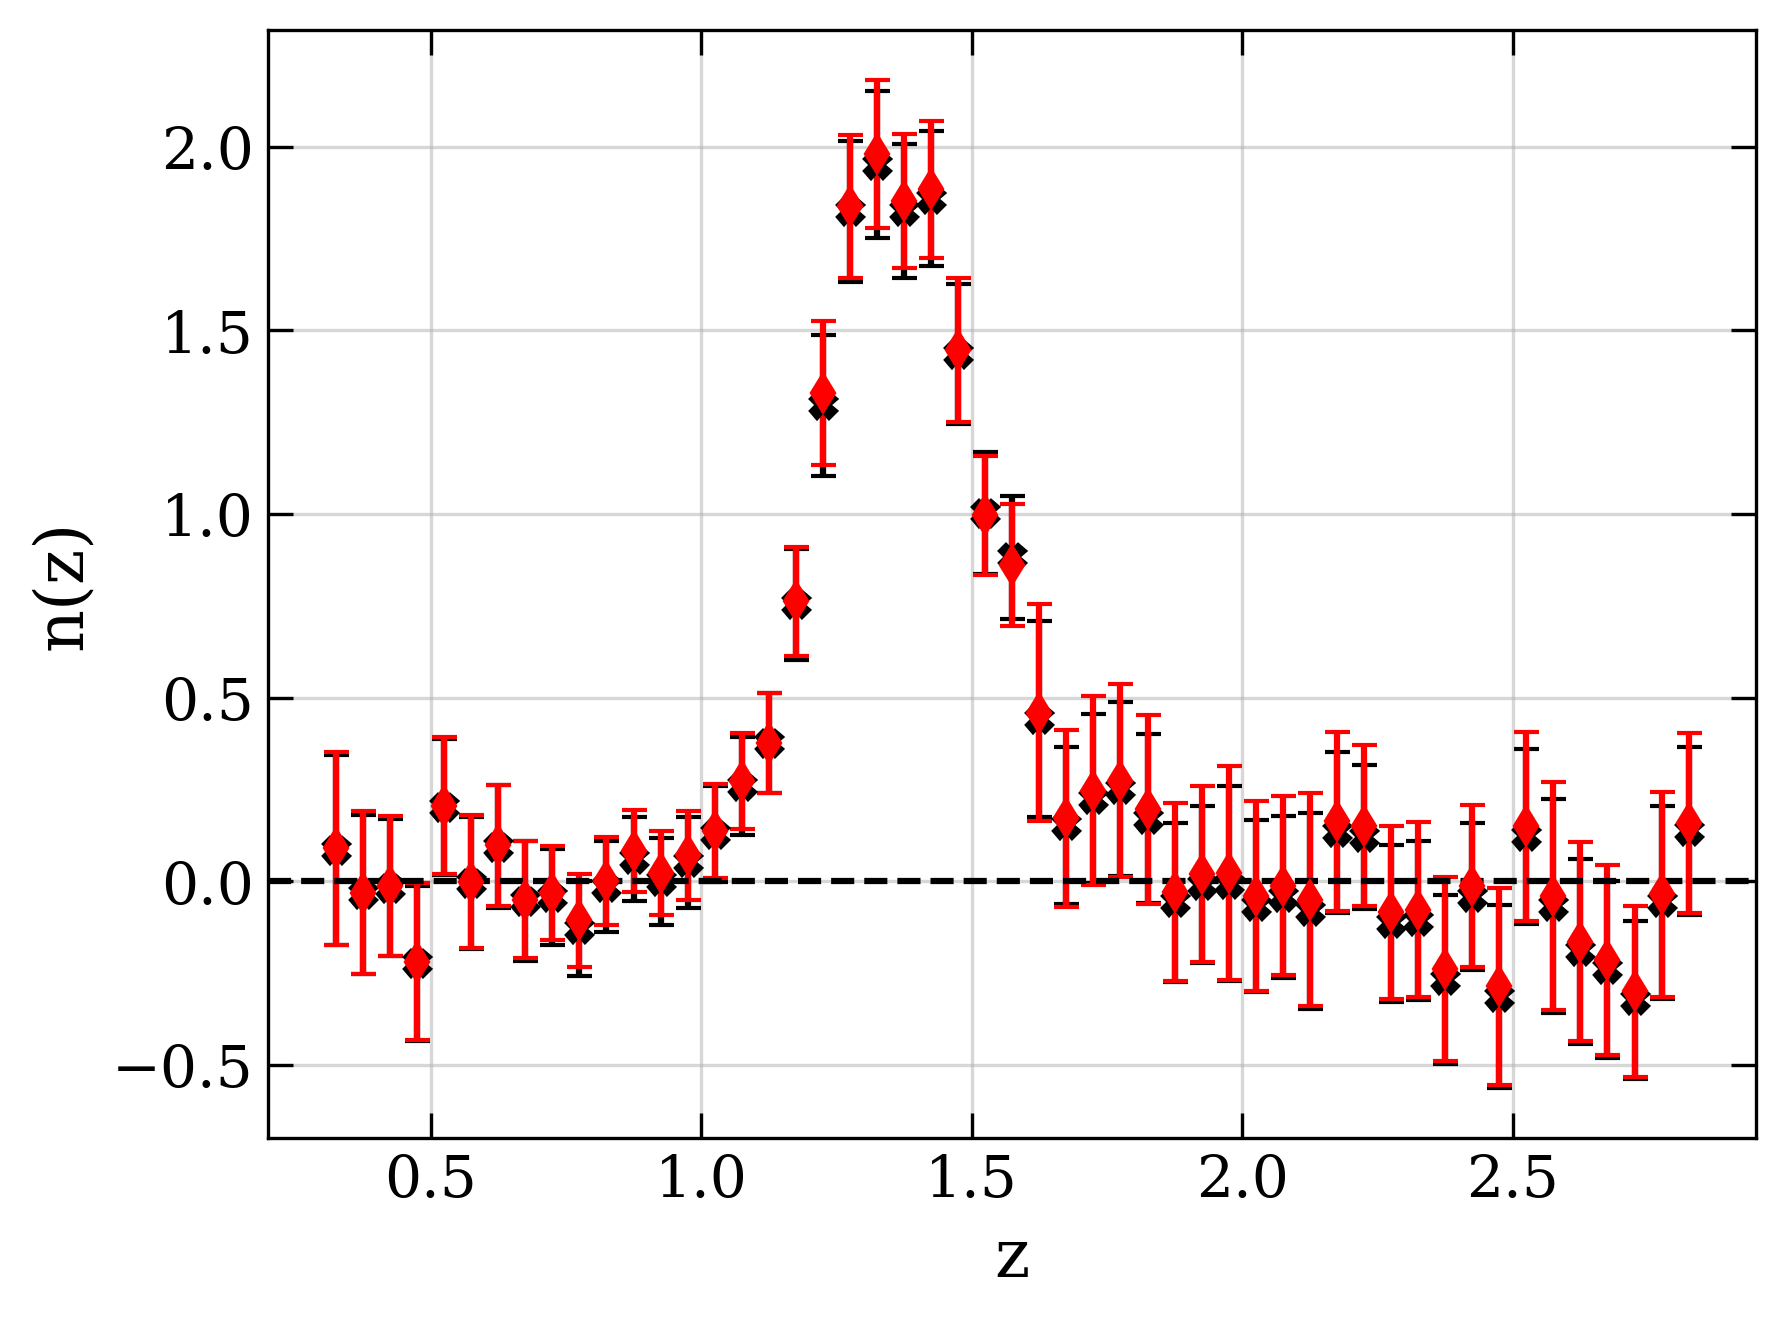

In [16]:
plt.errorbar(z, npz_raw, npz_raw_err, capsize=3, fmt='X', color='black', label='Raw n(z)')
plt.errorbar(z, npz_mag, npz_mag_err, capsize=3, fmt='d', color='red', label='n(z) corrected')
plt.grid(True)
plt.ylabel('n(z)')
plt.xlabel('z')
plt.axhline(0, color='black', linestyle='--')

In [17]:
spl_mag_1 = spline.BayesianBSpline(zv=z, n_knots=len(z)//2)
spl_mag_1.fit(npz_mag, npz_mag_err, n_tune=500, n_samples=2000, target_accept=0.97, prior_concentration=10)
spl_raw_1 = spline.BayesianBSpline(zv=z, n_knots=len(z)//2)
spl_raw_1.fit(npz_raw, npz_raw_err, n_tune=500, n_samples=2000, target_accept=0.97, prior_concentration=10)

Dirichlet alpha range: [0.180, 2.834]
Non-zero NNLS coefficients: 14 / 27


Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]
INFO:pymc.sampling.mcmc:NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 60 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 60 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


Model fitting complete. Summary:              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]   0.009  0.013   0.000    0.035      0.000    0.000    2366.0   
coeffs[1]   0.005  0.010   0.000    0.024      0.000    0.000    2568.0   
coeffs[2]   0.003  0.007   0.000    0.016      0.000    0.000    2452.0   
coeffs[3]   0.006  0.010   0.000    0.025      0.000    0.000    2545.0   
coeffs[4]   0.004  0.007   0.000    0.018      0.000    0.000    2753.0   
coeffs[5]   0.002  0.004   0.000    0.008      0.000    0.000    2851.0   
coeffs[6]   0.003  0.005   0.000    0.012      0.000    0.000    2010.0   
coeffs[7]   0.005  0.008   0.000    0.020      0.000    0.000    2337.0   
coeffs[8]   0.020  0.017   0.000    0.049      0.000    0.000    2505.0   
coeffs[9]   0.044  0.024   0.000    0.083      0.000    0.000    3872.0   
coeffs[10]  0.253  0.035   0.185    0.317      0.000    0.000    5616.0   
coeffs[11]  0.263  0.036   0.193    0.329      0.000    0.000    70

Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]
INFO:pymc.sampling.mcmc:NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 59 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 59 seconds.


Model fitting complete. Summary:              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]   0.009  0.013   0.000    0.035      0.000    0.000    2996.0   
coeffs[1]   0.004  0.009   0.000    0.021      0.000    0.000    2372.0   
coeffs[2]   0.003  0.007   0.000    0.017      0.000    0.000    2263.0   
coeffs[3]   0.006  0.010   0.000    0.025      0.000    0.000    2220.0   
coeffs[4]   0.004  0.007   0.000    0.017      0.000    0.000    2963.0   
coeffs[5]   0.002  0.004   0.000    0.008      0.000    0.000    2330.0   
coeffs[6]   0.002  0.004   0.000    0.011      0.000    0.000    2334.0   
coeffs[7]   0.003  0.006   0.000    0.015      0.000    0.000    2517.0   
coeffs[8]   0.019  0.016   0.000    0.049      0.000    0.000    3041.0   
coeffs[9]   0.045  0.025   0.000    0.085      0.000    0.000    3954.0   
coeffs[10]  0.256  0.034   0.192    0.320      0.000    0.000    6607.0   
coeffs[11]  0.267  0.036   0.197    0.334      0.000    0.000    67

NameError: name 'coeffs_samples' is not defined

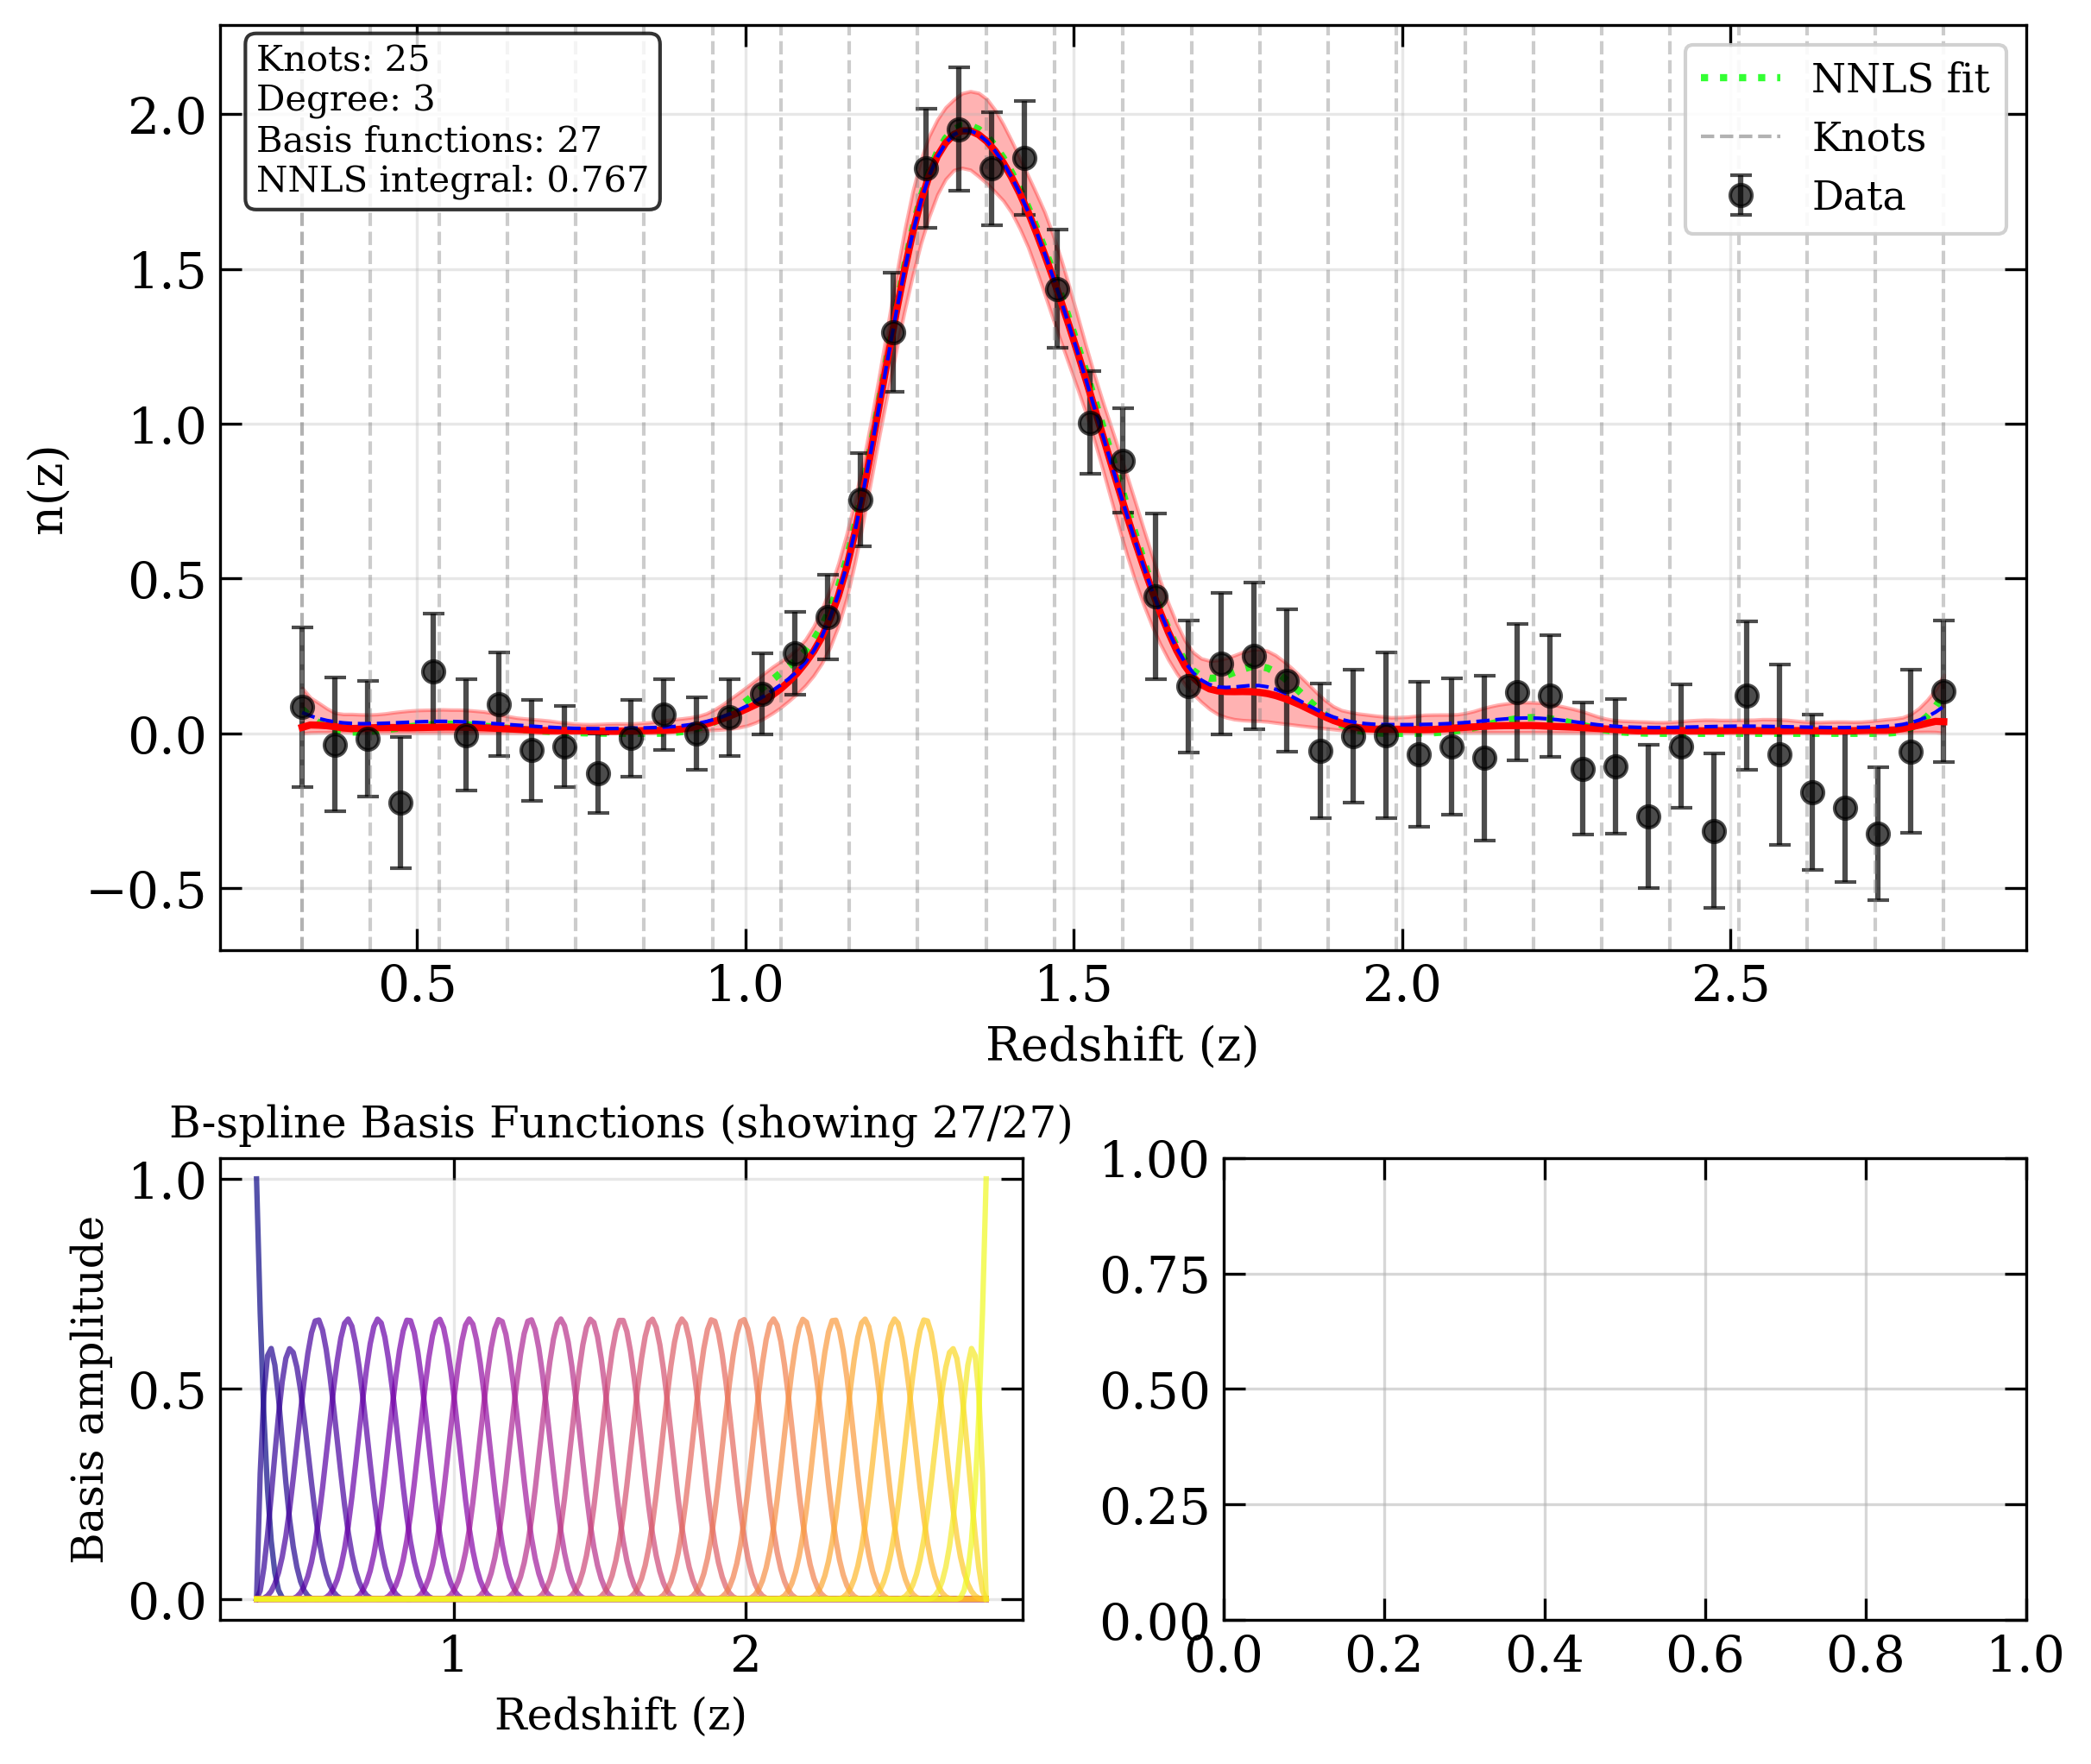

In [18]:
spl_raw_1.plot_fit(np.linspace(z.min(), z.max(), 200))
spl_mag_1.plot_fit(np.linspace(z.min(), z.max(), 200))

/tmp/ipykernel_1277357/286818735.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


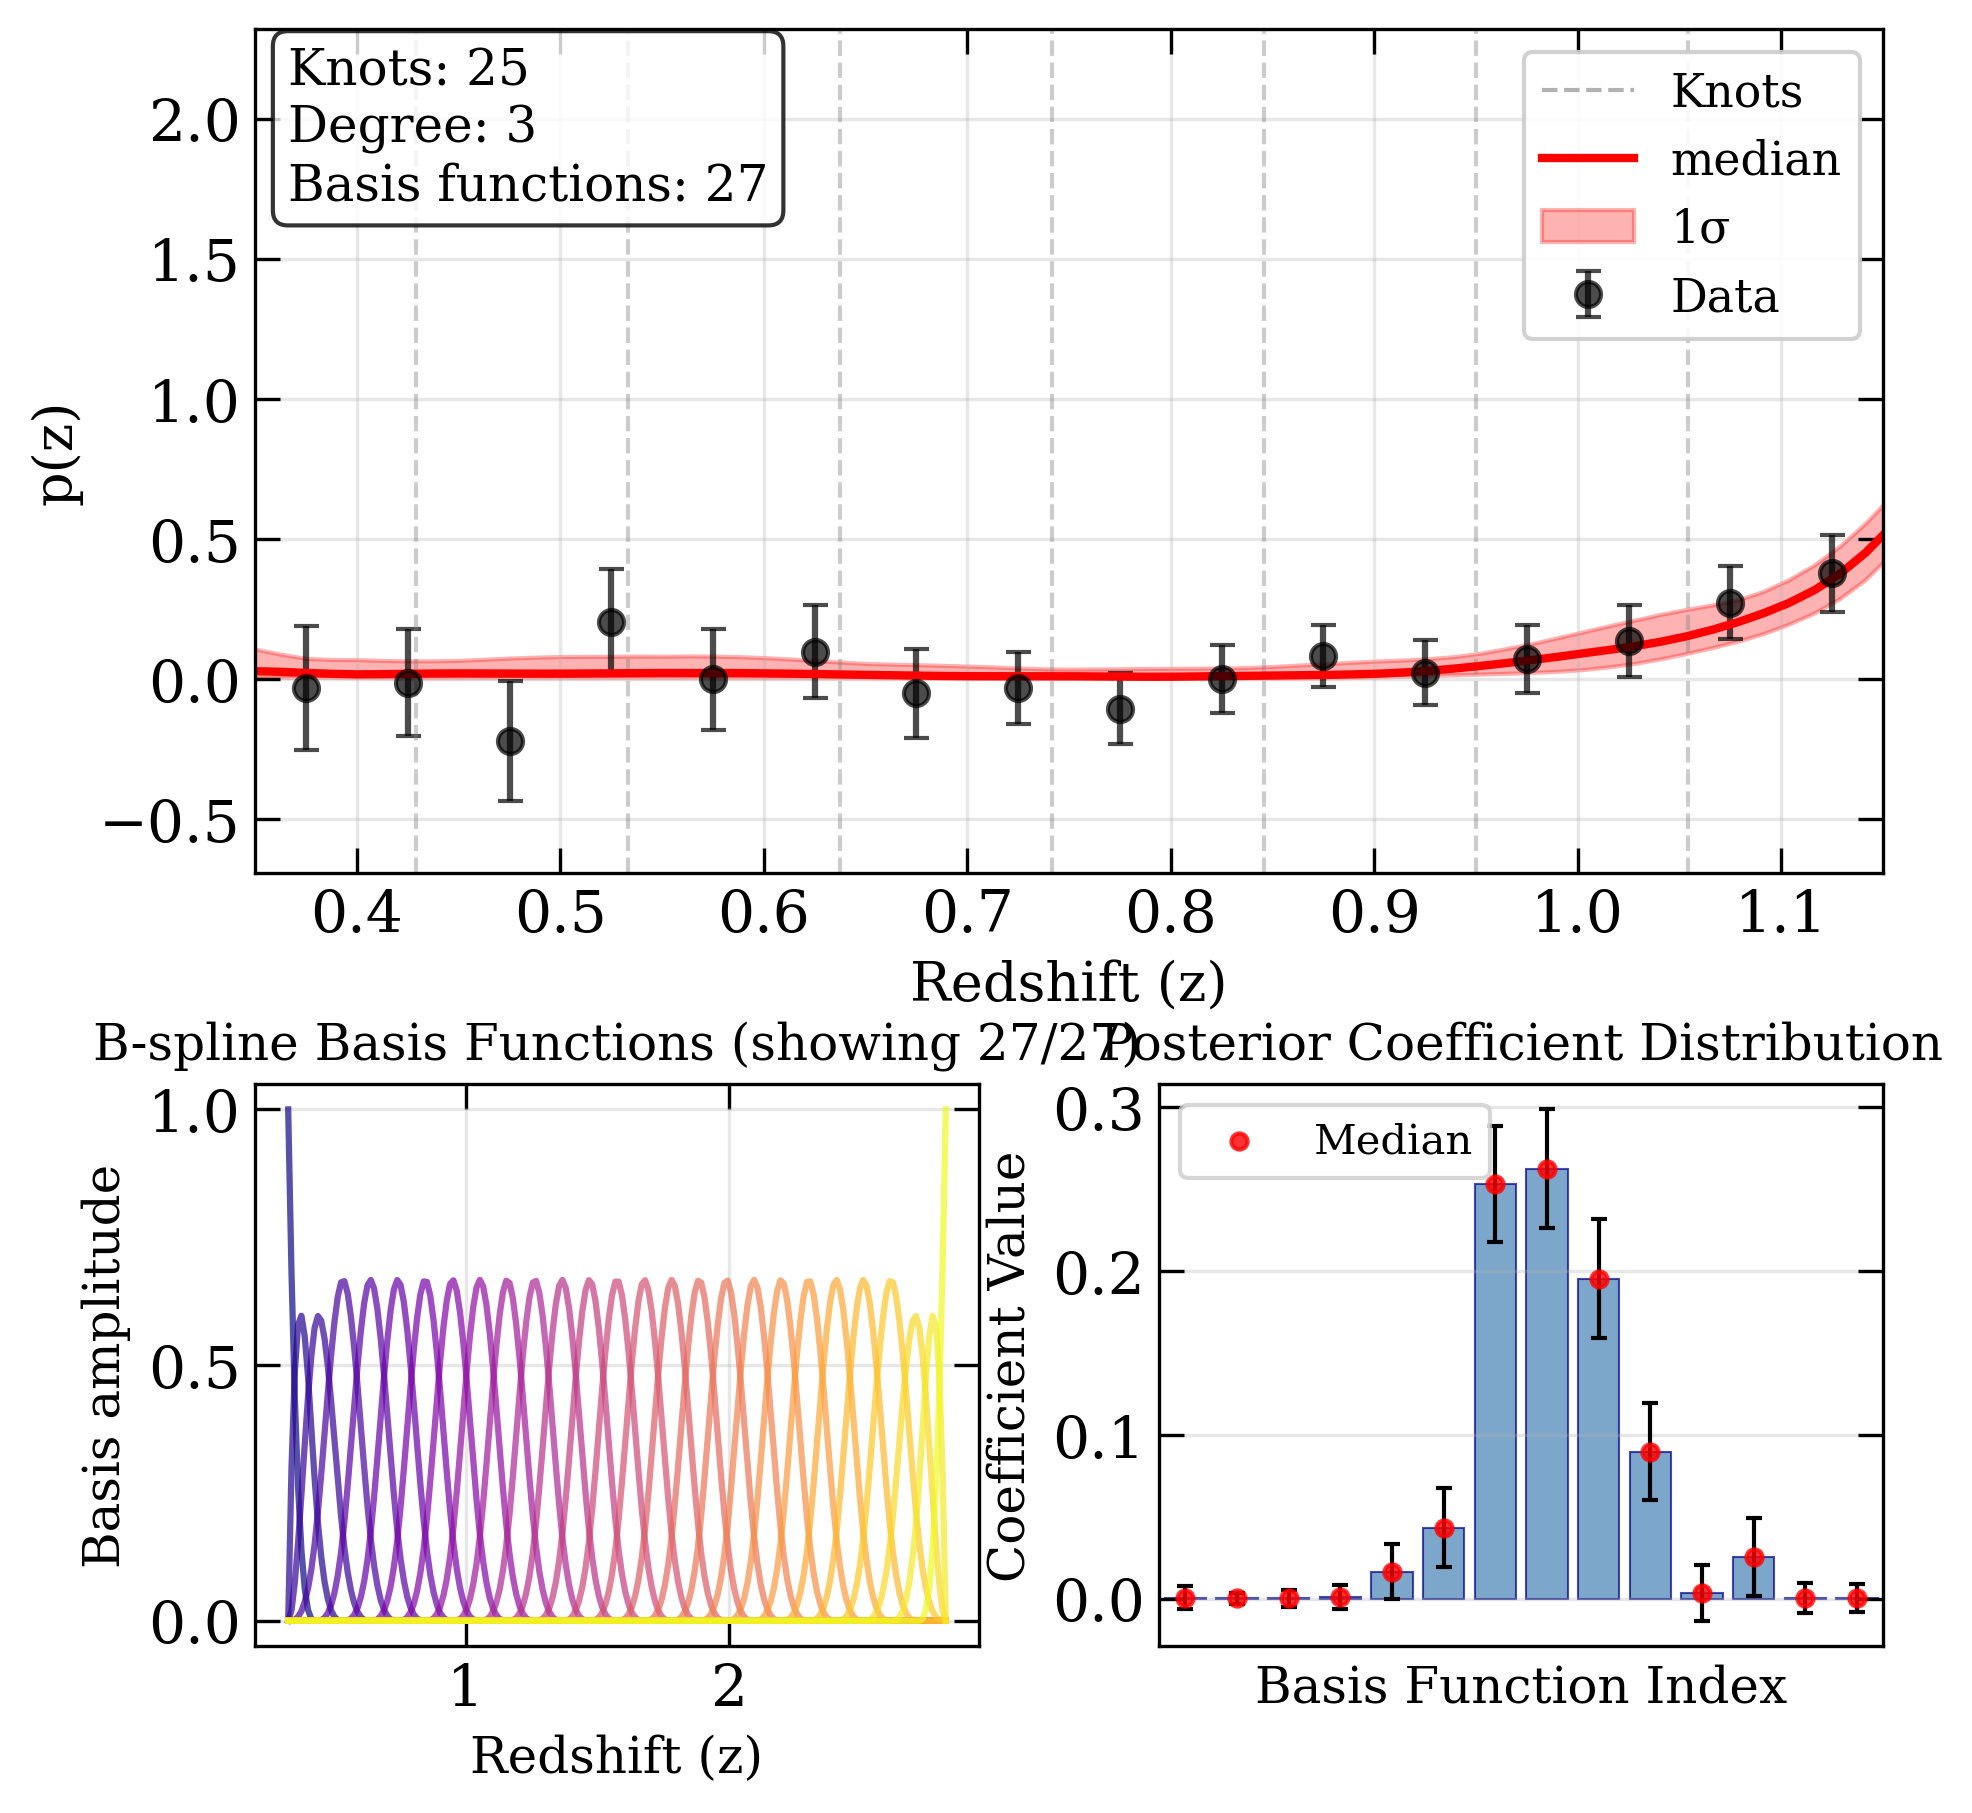

In [19]:
spl_study = spl_mag_1
show_knots = True
z_eval = np.linspace(z.min(), z.max(), 200)
n_eval_points=200
nz_samples = spl_study.get_samples(z_eval=z_eval, n_eval_points=n_eval_points)
basis_eval = spl_study._create_evaluation_basis(z_eval)

nz_median = np.percentile(nz_samples, 50, axis=0)
nz_mean = np.mean(nz_samples, axis=0)
nz_std = np.std(nz_samples, axis=0)
nz_lower = np.percentile(nz_samples, 16, axis=0)
nz_upper = np.percentile(nz_samples, 84, axis=0)

fig = plt.figure(figsize=(7,7))
gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1], hspace=0.3, wspace=0.25)
ax_main = fig.add_subplot(gs[0, :])

info_text = f'Knots: {spl_study.n_knots}\nDegree: {spl_study.degree}\nBasis functions: {spl_study.n_basis}'

ax_main.errorbar(
    spl_study.zv, 
    spl_study.nz, 
    yerr=spl_study.nz_err,
    fmt='o', 
    color='black',
    alpha=0.7,
    capsize=3, 
    capthick=1, 
    label='Data'
    )

if show_knots:
    knot_positions = spl_study.knots[spl_study.degree:-spl_study.degree]
    for i, knot in enumerate(knot_positions):
        alpha_val = 0.6 if i == 0 else 0.4
        label_val = 'Knots' if i == 0 else None
        ax_main.axvline(knot, color='gray', linestyle='--', alpha=alpha_val, 
                    linewidth=1, label=label_val)

ax_main.set_xlabel('Redshift (z)', fontsize=13)
ax_main.set_ylabel('p(z)', fontsize=13)
ax_main.grid(True, alpha=0.3)

ax_main.plot(
    z_eval, 
    nz_median, 
    color='red', 
    alpha=1,
    linewidth=2, 
    label='median'
    )
ax_main.fill_between(
    z_eval, 
    nz_lower, 
    nz_upper, 
    color='red', 
    alpha=0.3, 
    label='1σ'
    )

ax_main.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax_main.text(
    0.02, 
    0.98, 
    info_text, 
    transform=ax_main.transAxes,
    verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), 
    fontsize=12
    )
ax_main.set_xlim(0.35, 1.15)

ax_basis = fig.add_subplot(gs[1, 0])
n_show = spl_study.n_basis
indices = np.linspace(1, spl_study.n_basis, n_show, dtype=int)
colors = plt.cm.plasma(np.linspace(0, 1, n_show))

for i, idx in enumerate(indices):
    basis_func = basis_eval[:, i]
    ax_basis.plot(
        z_eval, 
        basis_func, 
        color=colors[i], 
        alpha=0.7, 
        linewidth=1.5, 
        label=f'B_{idx}' if n_show <= 6 else None
        )

ax_basis.set_xlabel('Redshift (z)', fontsize=12)
ax_basis.set_ylabel('Basis amplitude', fontsize=12)
ax_basis.set_title(f'B-spline Basis Functions (showing {n_show}/{spl_study.n_basis})', fontsize=12)
ax_basis.grid(True, alpha=0.3)
if n_show <= 6:
    ax_basis.legend(fontsize=9, ncol=2)

# Coefficient histogram (bottom right)
ax_coeff = fig.add_subplot(gs[1, 1])
coeff_means = np.mean(spl_study.coeffs_samples, axis=0)
coeff_stds = np.std(spl_study.coeffs_samples, axis=0)
coeff_medians = np.median(spl_study.coeffs_samples, axis=0)
x_pos = np.arange(spl_study.n_basis)

ax_coeff.bar(x_pos, coeff_medians, yerr=coeff_stds, 
                    capsize=2, alpha=0.7, color='steelblue',
                    edgecolor='darkblue', linewidth=0.5, error_kw={'linewidth': 1})

ax_coeff.scatter(x_pos, coeff_medians, color='red', s=15, alpha=0.8, 
                zorder=3, label='Median')

ax_coeff.set_xlabel('Basis Function Index', fontsize=12)
ax_coeff.set_ylabel('Coefficient Value', fontsize=12)
ax_coeff.set_title('Posterior Coefficient Distribution', fontsize=12)
ax_coeff.grid(True, alpha=0.3, axis='y')
ax_coeff.legend(fontsize=10)
ax_coeff.set_xlim(3+.5, 17+0.5)
ax_coeff.set_xticks([])

plt.tight_layout()

In [20]:
tomo_bin_dnnz = np.loadtxt('pz/data/tomographic_binning_dnnz.dat')
mids = tomo_bin_dnnz[:, 0]

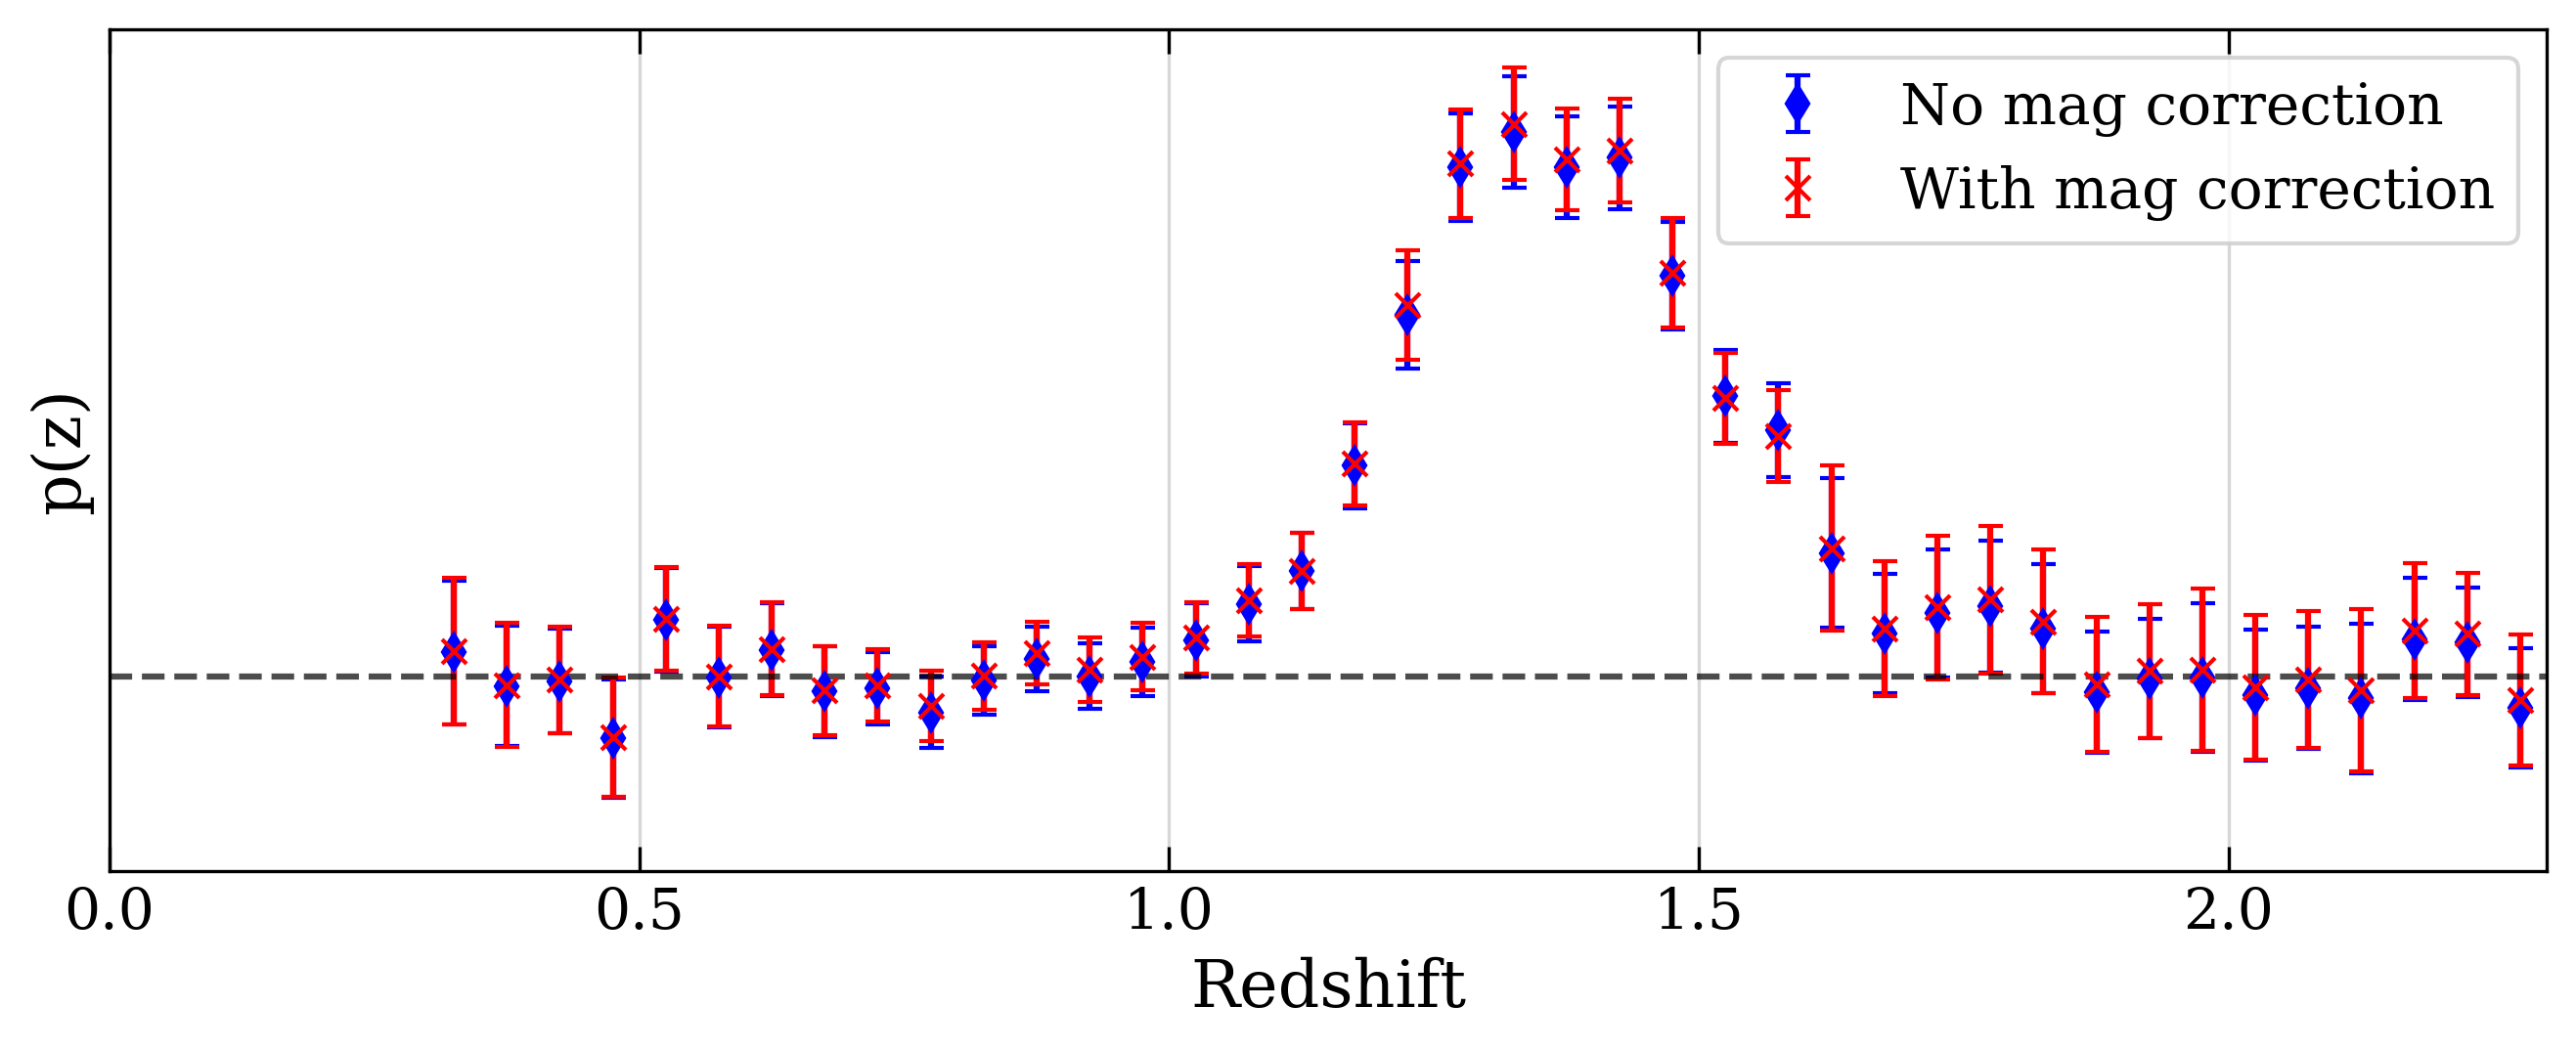

In [21]:
with pm.make_plot(name='magnification', show=True, figsize=(9, 3.8)) as (fig, ax):
    ax.errorbar(z, npz_raw, yerr=npz_raw_err, fmt='d', color='b', capsize=3, label="No mag correction")
    ax.errorbar(z, npz_mag, yerr=npz_mag_err, fmt='x', color='r', capsize=3, label="With mag correction")
    ax.grid(True)
    ax.axhline(0, color='black', alpha=0.7, linestyle='--')
    ax.legend()
    ax.set_xlabel("Redshift")
    ax.set_ylabel('p(z)')
    ax.set_xlim(0, 2.3)
    ax.set_yticks([])

0.12028995391221385


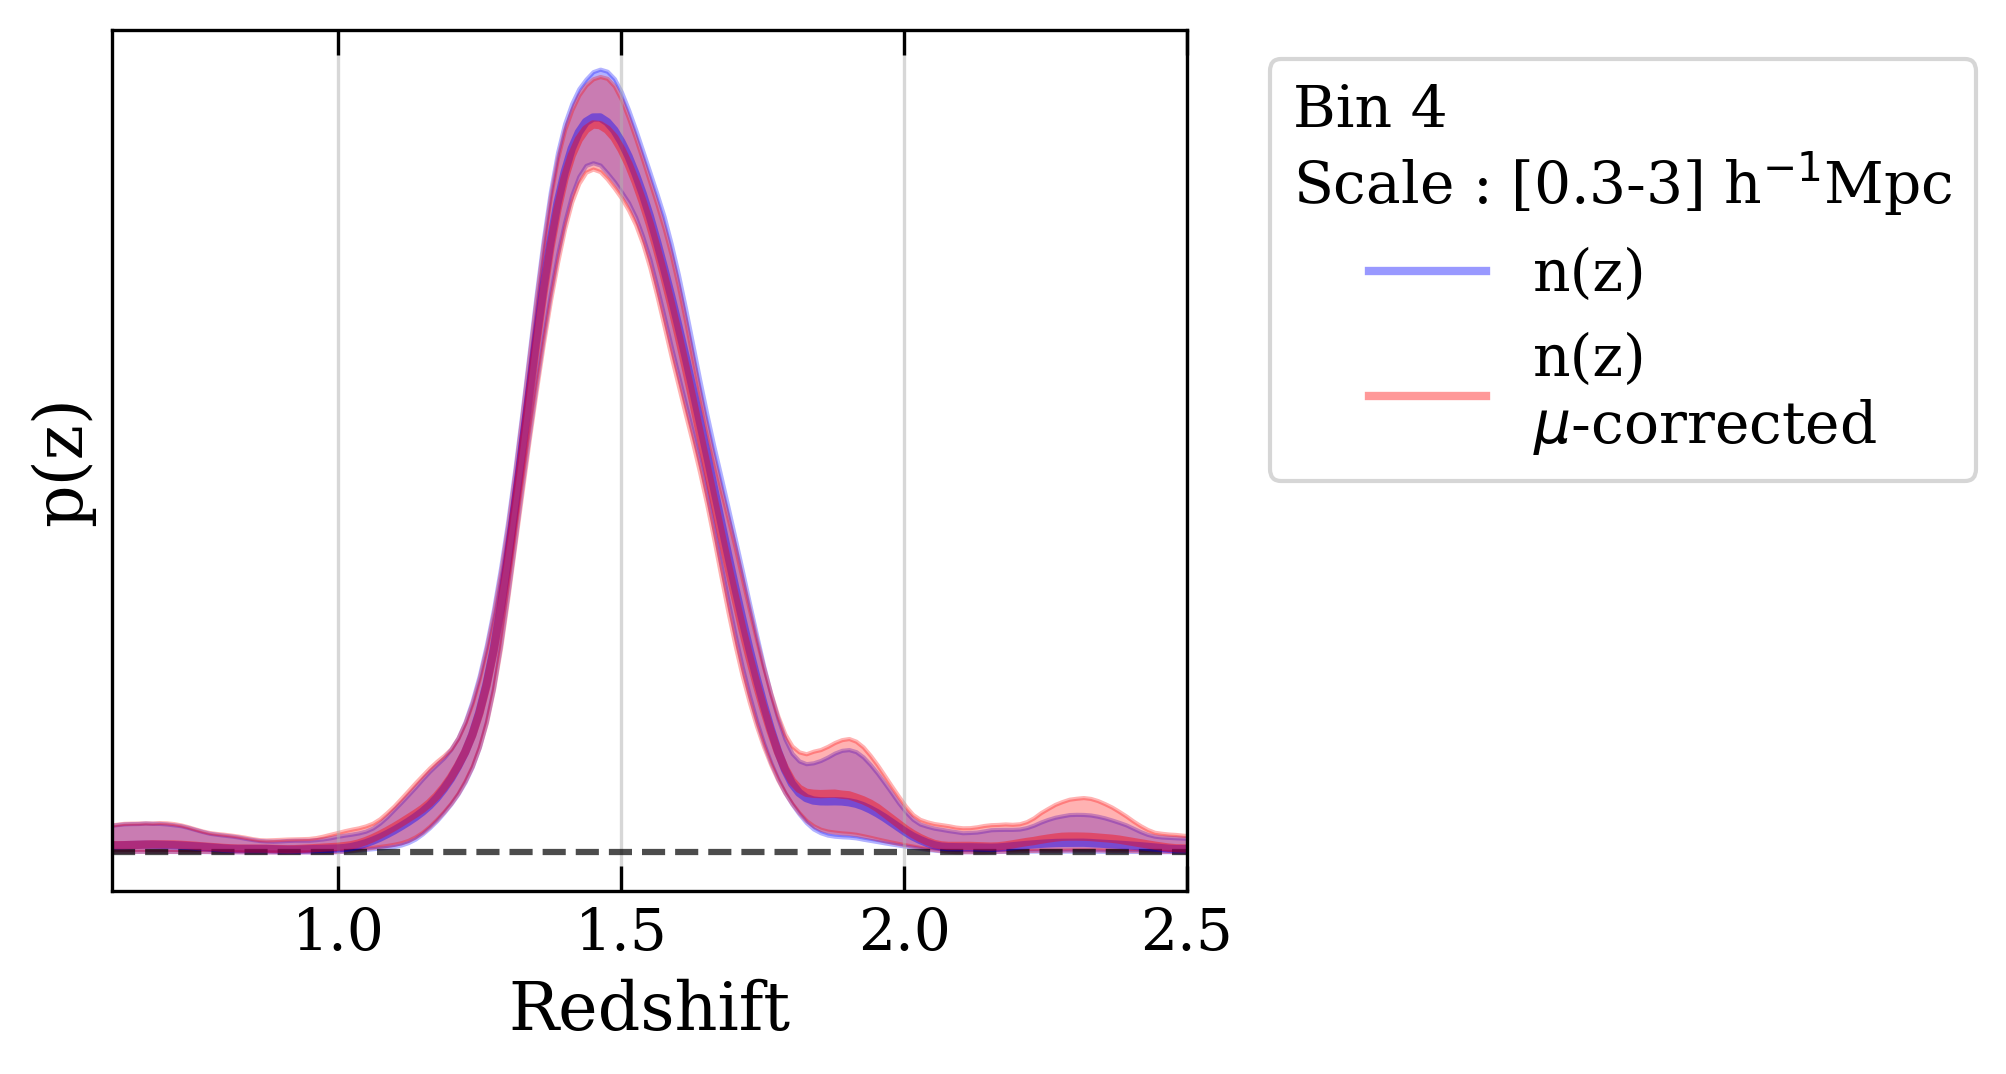

In [22]:
show_dnnz_phot = False
#3-> 42 -> 0.116
#4-> 123
gen = np.random.Generator(np.random.PCG64DXSM(123))
shift_param_blinded = gen.uniform(0.05, 0.15)
print(shift_param_blinded)

with pm.make_plot(name='magnification', show=True, figsize=(7, 3.8)) as (fig, ax):
    #ax.errorbar(z, npz_raw, yerr=npz_raw_err, fmt='d', color='b', capsize=3, label="No mag correction")
    #ax.errorbar(z, npz_mag, yerr=npz_mag_err, fmt='x', color='r', capsize=3, label="With mag correction")
    ax.grid(True)
    ax.axhline(0, color='black', alpha=0.7, linestyle='--')
    ax.set_xlabel("Redshift")
    ax.set_ylabel('p(z)')
    ax.set_xlim(0.6, 2.5)
    
    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tomo], mids)
    if show_dnnz_phot:
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[tomo](0.8), 
            hatch='//',
            alpha=0.2,
            label='DNNz Phot'
            )

    for spl, col, lab in zip([spl_raw_1, spl_mag_1], ['blue', 'red'], ['n(z)', 'n(z)\n'r'$\mu$-corrected']):
        z_eval = np.linspace(spl.zv.min(), spl.zv.max(), 200)

        basis_eval = spl._create_evaluation_basis(z_eval)
        coeffs_samples = spl.coeffs_samples

        amplitude_samples = spl.amplitude_samples
        nz_samples = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]

        nz_median = np.percentile(nz_samples, 50, axis=0)
        nz_mean = np.mean(nz_samples, axis=0)
        nz_std = np.std(nz_samples, axis=0)
        nz_lower = np.percentile(nz_samples, 16, axis=0)
        nz_upper = np.percentile(nz_samples, 84, axis=0)

        integ = np.trapezoid(nz_median, z_eval)
        
        ax.plot(
            z_eval+shift_param_blinded, 
            nz_median/integ, 
            color=col, 
            alpha=0.4,
            linewidth=2, 
            label=lab
            )
        ax.fill_between(
            z_eval+shift_param_blinded, 
            nz_lower/integ, 
            nz_upper/integ, 
            color=col, 
            alpha=0.3, 
            )
        
    #ax.errorbar(z+shift_param_blinded, npz_raw/integ, yerr=npz_raw_err/integ, fmt='d', color='b', capsize=3)
    #ax.errorbar(z+shift_param_blinded, npz_mag/integ, yerr=npz_mag_err/integ, fmt='x', color='r', capsize=3)
    ax.legend(title=f'Bin {tomo}\nScale : [0.3-3] '+r'h$^{-1}$Mpc', loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.set_yticks([])
    #ax.set_xticks([])

In [13]:
%pip install dill
import dill
save_splines = Path('splines')
save_splines.mkdir(exist_ok=True)
with open(save_splines / f'spline_raw_{tomo}.pkl', 'wb') as f:
    dill.dump(spl_raw_1, f)
with open(save_splines / f'spline_mag_{tomo}.pkl', 'wb') as f:
    dill.dump(spl_mag_1, f)

Note: you may need to restart the kernel to use updated packages.
